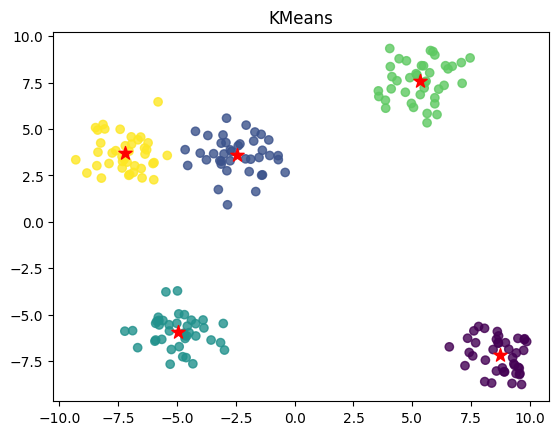

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
 
# create a dataset of 200 samples
# and 5 clusters
features, labels = make_blobs(
    n_samples=200,
    centers=5
)
 
# Instanciate the model with 5 'K' clusters
# and 10 iterations with different
# centroid seed 
model = KMeans(
    n_clusters=5,
    n_init=10,
    random_state=42
    )
 
# train the model
model.fit(features)
 
# make a prediction on the data
p_labels = model.predict(features)

import matplotlib.pyplot as plt
plt.style.use('default')
 
X = features[:,0]
y = features[:,1]
 
plt.scatter(X, y, c=p_labels, alpha=0.8)
 
cluster_centers = model.cluster_centers_
cs_x = cluster_centers[:,0]
cs_y = cluster_centers[:,1]
 
plt.scatter(cs_x, cs_y, marker='*', s=100, c='r')
plt.title('KMeans')
plt.show()


In [14]:
cluster_centers

array([[ 8.73113053, -7.17856771],
       [-2.46467814,  3.60128191],
       [-4.96702628, -5.92625997],
       [ 5.34797758,  7.57939364],
       [-7.19567671,  3.68880121]])

In [16]:
import numpy as np
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import json

token_provider = get_bearer_token_provider(
    DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
  azure_endpoint = "https://aifsweden.openai.azure.com/", 
  azure_ad_token_provider=token_provider,
  api_version="2025-03-01-preview"
)

response = client.responses.create(
    model="gpt-5-mini",
    #temperature=0.7,
    reasoning={"effort": "medium"},
    input="""Take this data and split into 5 clusters same way as k means clustering might do. I just want the location of the 5 clusters not the code:""" + json.dumps(features.tolist()) + "  labels are : " + json.dumps(labels.tolist()),
)

print(response.output_text)

print(response.usage)


Here are the 5 cluster centroids (label : [x, y]) computed from the provided points/labels:

- Cluster 0: [8.731131, -7.178568]  
- Cluster 1: [-2.952230, 3.706633]  
- Cluster 2: [-4.743500, -2.990317]  
- Cluster 3: [5.045219, 7.455847]  
- Cluster 4: [-6.781857, 4.057345]

Let me know if you want them rounded differently or returned in another order/format.
ResponseUsage(input_tokens=4329, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=25992, output_tokens_details=OutputTokensDetails(reasoning_tokens=25856), total_tokens=30321)
